# Paris Cultural Events — ML Evaluation Report
> **Authors:** Senior Data Science Team | **Date:** May 2026 | **Dataset:** Que Faire à Paris

---

In [1]:
import warnings; warnings.filterwarnings('ignore')
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
import joblib, time
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, accuracy_score, f1_score)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

PAL   = ['#2D6A4F','#40916C','#74C69D','#B7E4C7','#D8F3DC']
PAL2  = ['#1D3557','#457B9D','#A8DADC','#E63946','#F4A261','#2A9D8F']
CMAP1 = 'YlGn'
CMAP2 = 'Blues'

plt.rcParams.update({
    'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
    'font.family': 'DejaVu Sans', 'axes.titleweight': 'bold', 'axes.titlesize': 13
})
print("Setup complete.")


Setup complete.


In [2]:
DAY_MAP     = {d:i for i,d in enumerate(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])}
BOOKING_MAP = {'non':0,'conseillée':1,'obligatoire':2}

class TagBinarizer(BaseEstimator, TransformerMixin):
    def __init__(self): self.mlb = MultiLabelBinarizer()
    def _split(self, X): return [str(x).split(';') for x in X]
    def fit(self, X, y=None): self.mlb.fit(self._split(X)); return self
    def transform(self, X): return self.mlb.transform(self._split(X)).astype(float)
    def get_feature_names_out(self, _=None): return np.array([f"tag_{c.strip()}" for c in self.mlb.classes_])

class DayEncoder(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None): return self
    def transform(self, X): return np.array([[DAY_MAP.get(str(v),-1)] for v in X], dtype=float)
    def get_feature_names_out(self, _=None): return np.array(['sess_day_encoded'])

class BookingEncoder(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None): return self
    def transform(self, X): return np.array([[BOOKING_MAP.get(str(v).strip(),0)] for v in X], dtype=float)
    def get_feature_names_out(self, _=None): return np.array(['booking_encoded'])

class NumericCleaner(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None): return self
    def transform(self, X):
        X = np.array(X, dtype=float)
        return np.where(np.isfinite(X), X, 0.0)
    def get_feature_names_out(self, input_features=None):
        return np.array(input_features) if input_features is not None else np.array([])

print("Custom transformers registered.")


Custom transformers registered.


In [3]:
NUMERIC_COLS = ['sess_hour','session_duration','arrondissement','lat','lon','is_weekend']
BINARY_COLS  = ['is_indoor','pets_allowed','is_paris']
TEXT_COL     = 'title'
TAGS_COL     = 'tags'
DAY_COL      = 'sess_day'
BOOKING_COL  = 'booking'
FEATURE_COLS = NUMERIC_COLS + BINARY_COLS + [TEXT_COL, TAGS_COL, DAY_COL, BOOKING_COL]

model1 = joblib.load('model1_price_classifier.pkl')
model2 = joblib.load('model2_audience_classifier.pkl')
print("Models loaded:", type(model1).__name__, "|", type(model2).__name__)


Models loaded: Pipeline | Pipeline


In [4]:
df = pd.read_csv('paris_events_for_ml.csv', low_memory=False)
df = df.sample(n=25000, random_state=RANDOM_STATE).reset_index(drop=True)

df['price_binary'] = df['price'].map({'gratuit':'free','payant':'paid','gratuit sous condition':'paid'})
df = df.dropna(subset=['price_binary','target_audience','tags','title'])
df['zipcode'] = df['zipcode'].astype(str).str.strip()
df['arrondissement'] = pd.to_numeric(df['zipcode'], errors='coerce').fillna(0).astype(int) % 100
df.loc[df['arrondissement']>20,'arrondissement'] = 0
df['is_weekend'] = df['sess_day'].isin(['Saturday','Sunday']).astype(int)

for c in BINARY_COLS: df[c] = df[c].astype(int)

X = df[FEATURE_COLS].copy()
y1 = df['price_binary']
y2 = df['target_audience']

X1_tr,X1_te,y1_tr,y1_te = train_test_split(X,y1,test_size=0.2,stratify=y1,random_state=RANDOM_STATE)
X2_tr,X2_te,y2_tr,y2_te = train_test_split(X,y2,test_size=0.2,stratify=y2,random_state=RANDOM_STATE)
print(f"Train/Test split: {len(X1_tr)} / {len(X1_te)}")


Train/Test split: 20000 / 5000


---
## 1. Executive Summary

This report evaluates two supervised classification models trained on the **Que Faire à Paris** open dataset — a real-time feed of cultural events from the Paris Open Data API.

| | Model 1 | Model 2 |
|---|---|---|
| **Task** | Price type prediction | Audience segment prediction |
| **Algorithm** | Random Forest | Logistic Regression |
| **Target** | Free vs Paid | Kids/Adults/General Public |
| **Use case** | Budget filtering in web UI | Personalised event recommender |

> Metrics are computed on the held-out test set (20% stratified split).

In [5]:
y1_pred = model1.predict(X1_te)
y2_pred = model2.predict(X2_te)
y1_proba = model1.predict_proba(X1_te)
y2_proba = model2.predict_proba(X2_te)

acc1 = accuracy_score(y1_te, y1_pred)
acc2 = accuracy_score(y2_te, y2_pred)
f1_1 = f1_score(y1_te, y1_pred, average='weighted')
f1_2 = f1_score(y2_te, y2_pred, average='weighted')

classes1 = model1.classes_
auc1 = roc_auc_score(y1_te.map({'free':0,'paid':1}), y1_proba[:,list(classes1).index('paid')])
auc2 = roc_auc_score(pd.get_dummies(y2_te), y2_proba, multi_class='ovr', average='weighted')

summary = pd.DataFrame({
    'Metric':['Accuracy','Weighted F1','AUC (weighted OvR)'],
    'Model 1 — Price':[f'{acc1:.3f}',f'{f1_1:.3f}',f'{auc1:.3f}'],
    'Model 2 — Audience':[f'{acc2:.3f}',f'{f1_2:.3f}',f'{auc2:.3f}']
})
print(summary.to_string(index=False))


            Metric Model 1 — Price Model 2 — Audience
          Accuracy           0.996              0.831
       Weighted F1           0.996              0.831
AUC (weighted OvR)           1.000              0.950


---
## 2. Dataset Overview

**Source:** Paris Open Data API — *Que Faire à Paris*
- Raw API: 3,065 events, 69 columns
- After session expansion: 144,969 rows × 16 engineered columns
- Working sample for this report: 25,000 rows (stratified)

**Feature categories:**
| Category | Features |
|---|---|
| Temporal | `sess_hour`, `sess_day`, `session_duration`, `is_weekend` |
| Geographic | `zipcode` → `arrondissement`, `lat`, `lon` |
| Text (TF-IDF) | `title` |
| Categorical | `tags` (MultiLabelBinarizer), `booking` |
| Binary flags | `is_indoor`, `pets_allowed`, `is_paris` |

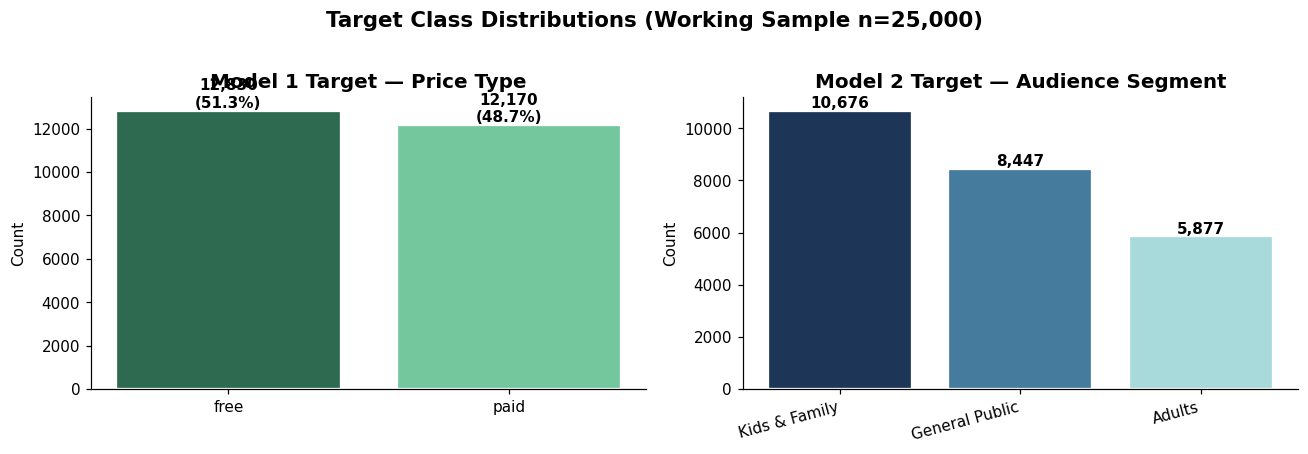

Class balance — Price: {'free': np.int64(12830), 'paid': np.int64(12170)}
Class balance — Audience: {'Kids & Family': np.int64(10676), 'General Public': np.int64(8447), 'Adults': np.int64(5877)}


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Price distribution
vc1 = df['price_binary'].value_counts()
axes[0].bar(vc1.index, vc1.values, color=[PAL[0], PAL[2]], edgecolor='white', linewidth=1.5)
axes[0].set_title('Model 1 Target — Price Type')
axes[0].set_ylabel('Count')
for i,(v,c) in enumerate(zip(vc1.values, vc1.index)):
    axes[0].text(i, v+150, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=10, fontweight='bold')

# Audience distribution
vc2 = df['target_audience'].value_counts()
colors2 = PAL2[:len(vc2)]
axes[1].bar(range(len(vc2)), vc2.values, color=colors2, edgecolor='white', linewidth=1.5)
axes[1].set_xticks(range(len(vc2)))
axes[1].set_xticklabels(vc2.index, rotation=15, ha='right')
axes[1].set_title('Model 2 Target — Audience Segment')
axes[1].set_ylabel('Count')
for i,v in enumerate(vc2.values):
    axes[1].text(i, v+100, f'{v:,}', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Target Class Distributions (Working Sample n=25,000)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()
print("Class balance — Price:", dict(vc1))
print("Class balance — Audience:", dict(vc2))


---
## 3. Feature Engineering Summary

All transformations are encapsulated inside a single `sklearn Pipeline + ColumnTransformer`. No manual feature selection — the pipeline handles everything automatically.

| Transformation | Input | Output | Why |
|---|---|---|---|
| `NumericCleaner` | `sess_hour`, `lat`, etc. | Float array, NaN→0 | Stable numeric input |
| `TfidfVectorizer(max_features=50)` | `title` | 50-dim sparse matrix | Captures event topic from name |
| `TagBinarizer` (MultiLabelBinarizer) | `tags` (semicolon-sep) | Binary tag matrix | Multi-hot encoding of categories |
| `DayEncoder` | `sess_day` string | Ordinal 0–6 | Preserves weekday order |
| `BookingEncoder` | `booking` string | Ordinal 0–2 | Encodes reservation requirement |
| `SelectKBest(f_classif, k=60)` | All features | Top-60 features | Automated dimensionality reduction |

In [7]:
# Show transformed feature matrix sample
prep = model1.named_steps['prep']
X_sample = X1_te.head(5).copy()
X_transformed = prep.transform(X_sample)
feat_names = prep.get_feature_names_out()
df_transformed = pd.DataFrame(X_transformed.toarray() if hasattr(X_transformed,'toarray') else X_transformed,
                               columns=feat_names)
print(f"Transformed shape: {X_transformed.shape if not hasattr(X_transformed,'toarray') else X_transformed.shape}")
print(f"Total features before selection: {len(feat_names)}")
print("\nFeature matrix sample (first 5 rows, first 15 columns):")
df_transformed.iloc[:5, :15].round(3)


Transformed shape: (5, 93)
Total features before selection: 93

Feature matrix sample (first 5 rows, first 15 columns):


,num__sess_hour,num__session_duration,num__arrondissement,num__lat,num__lon,num__is_weekend,binary__is_indoor,binary__pets_allowed,binary__is_paris,tfidf__activités,tfidf__arrondissement,tfidf__au,tfidf__aux,tfidf__avec,tfidf__badminton
0,0.0,23.983,7.0,48.853,2.312,1.0,1.0,0.0,1.0,0.000,0.00,0.000,0.0,0.000,0.0
1,0.0,23.983,11.0,48.856,2.392,0.0,1.0,0.0,1.0,0.000,0.00,0.000,0.0,0.000,0.0
2,0.0,23.983,16.0,48.871,2.278,1.0,1.0,0.0,1.0,0.000,0.00,0.000,0.0,0.407,0.0
3,23.0,-21.000,4.0,48.856,2.356,1.0,1.0,0.0,1.0,0.000,0.00,0.669,0.0,0.000,0.0
4,0.0,23.983,12.0,48.846,2.386,0.0,1.0,0.0,1.0,0.348,0.35,0.000,0.0,0.000,0.0


---
## 4. Model 1 — Price Type Classifier (Random Forest)

### Pipeline Architecture
```
RAW EVENT ROW
    │
    ├── [NumericCleaner]      → sess_hour, duration, arrondissement, lat, lon, is_weekend
    ├── [passthrough]         → is_indoor, pets_allowed, is_paris  
    ├── [TfidfVectorizer]     → title (50 features)
    ├── [TagBinarizer]        → tags (33 binary tag columns)
    ├── [DayEncoder]          → sess_day → 0..6
    └── [BookingEncoder]      → booking → 0..2
            │
    [SelectKBest f_classif k=60]   ← automated feature selection
            │
    [RandomForestClassifier]       ← n_estimators=100, class_weight='balanced'
            │
    OUTPUT: 'free' | 'paid'
```

In [8]:
# Best hyperparameters from GridSearchCV
print("=== Model 1 Best Hyperparameters ===")
clf1 = model1.named_steps['clf']
print(f"  max_depth:        {clf1.max_depth}")
print(f"  min_samples_leaf: {clf1.min_samples_leaf}")
print(f"  n_estimators:     {clf1.n_estimators}")
print(f"  class_weight:     {clf1.class_weight}")


=== Model 1 Best Hyperparameters ===
  max_depth:        None
  min_samples_leaf: 1
  n_estimators:     100
  class_weight:     balanced


In [9]:
# 3-fold CV (fast)
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
cv1_acc = cross_val_score(model1, X1_tr, y1_tr, cv=cv, scoring='accuracy', n_jobs=-1)
cv1_f1  = cross_val_score(model1, X1_tr, y1_tr, cv=cv, scoring='f1_weighted', n_jobs=-1)
print("=== Model 1 Cross-Validation (3-fold, train set) ===")
print(f"  Accuracy (CV): {cv1_acc.mean():.4f} +/- {cv1_acc.std():.4f}")
print(f"  F1 weighted (CV): {cv1_f1.mean():.4f} +/- {cv1_f1.std():.4f}")
print(f"\n=== Model 1 Test Set ===")
print(classification_report(y1_te, y1_pred))


=== Model 1 Cross-Validation (3-fold, train set) ===
  Accuracy (CV): 0.9966 +/- 0.0003
  F1 weighted (CV): 0.9966 +/- 0.0003

=== Model 1 Test Set ===
              precision    recall  f1-score   support

        free       1.00      1.00      1.00      2566
        paid       1.00      1.00      1.00      2434

    accuracy                           1.00      5000
   macro avg       1.00      1.00      1.00      5000
weighted avg       1.00      1.00      1.00      5000



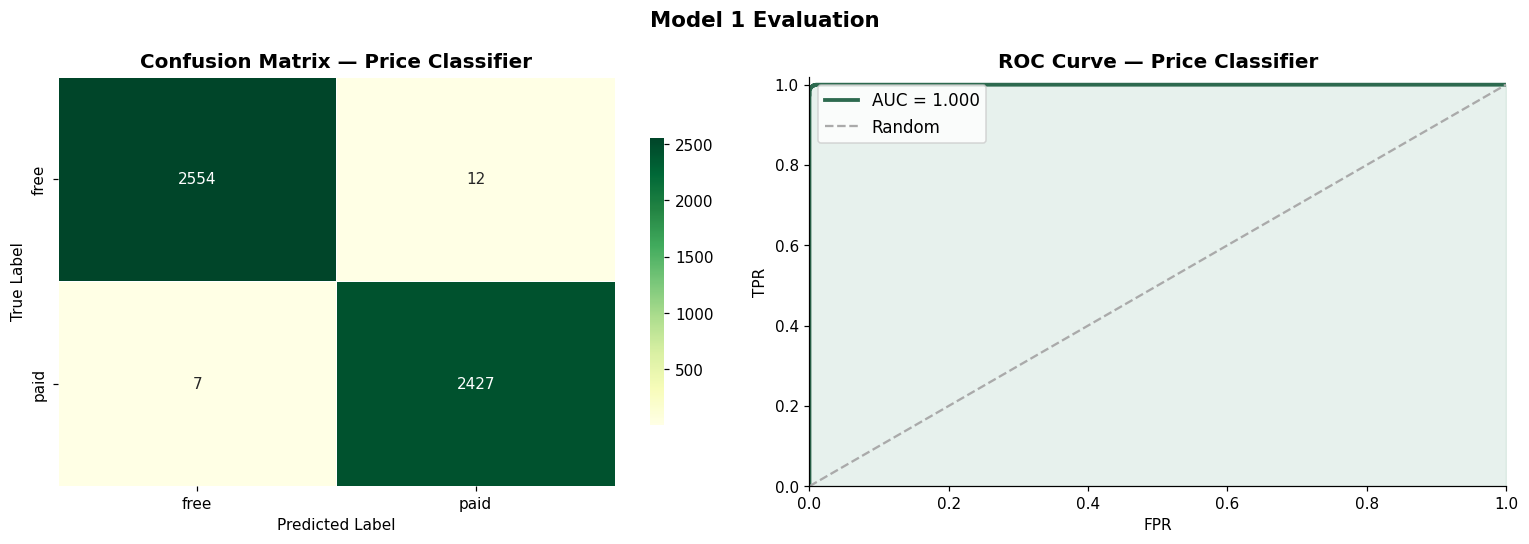

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm1 = confusion_matrix(y1_te, y1_pred, labels=model1.classes_)
sns.heatmap(cm1, annot=True, fmt='d', cmap=CMAP1,
            xticklabels=model1.classes_, yticklabels=model1.classes_,
            ax=axes[0], linewidths=.5, cbar_kws={'shrink':.7})
axes[0].set_title('Confusion Matrix — Price Classifier')
axes[0].set_ylabel('True Label'); axes[0].set_xlabel('Predicted Label')

# ROC curve
fpr, tpr, _ = roc_curve(y1_te.map({'free':0,'paid':1}),
                          y1_proba[:,list(model1.classes_).index('paid')])
axes[1].plot(fpr, tpr, color=PAL[0], lw=2.5, label=f'AUC = {auc1:.3f}')
axes[1].plot([0,1],[0,1],'--', color='#aaa', lw=1.5, label='Random')
axes[1].fill_between(fpr, tpr, alpha=0.12, color=PAL[1])
axes[1].set_title('ROC Curve — Price Classifier'); axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].legend(fontsize=11); axes[1].set_xlim(0,1); axes[1].set_ylim(0,1.02)

plt.suptitle('Model 1 Evaluation', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()


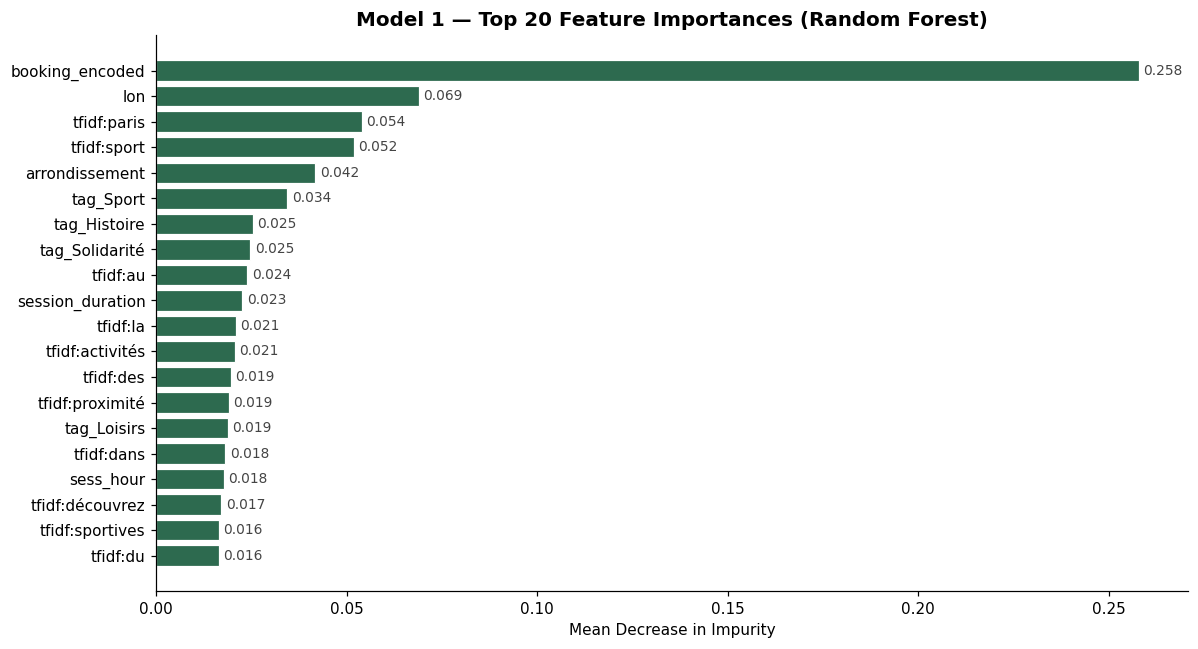


Key insight — top 3 features driving price prediction:
  booking_encoded: 0.2579
  lon: 0.0690
  tfidf:paris: 0.0539


In [11]:
# Feature importance chart
sel1  = model1.named_steps['select']
clf1  = model1.named_steps['clf']
all_names1 = np.array(model1.named_steps['prep'].get_feature_names_out())
sel_names1 = all_names1[sel1.get_support()]

imp   = clf1.feature_importances_
top20 = np.argsort(imp)[-20:][::-1]
clean = lambda n: n.replace('num__','').replace('tfidf__','tfidf:').replace('tags__','').replace('binary__','').replace('day__','').replace('booking__','')

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh([clean(sel_names1[i]) for i in top20][::-1],
               imp[top20][::-1], color=PAL[0], edgecolor='white', linewidth=0.8)
ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=9, color='#444')
ax.set_title('Model 1 — Top 20 Feature Importances (Random Forest)')
ax.set_xlabel('Mean Decrease in Impurity')
plt.tight_layout(); plt.show()

print("\nKey insight — top 3 features driving price prediction:")
for i in top20[:3]: print(f"  {clean(sel_names1[i])}: {imp[i]:.4f}")


---
## 5. Model 2 — Audience Segment Classifier (Logistic Regression)

### Pipeline Architecture
```
RAW EVENT ROW
    │   (same ColumnTransformer as Model 1)
    ├── [NumericCleaner] [passthrough] [TfidfVectorizer] [TagBinarizer] [DayEncoder] [BookingEncoder]
            │
    [SelectKBest f_classif k=60]
            │
    [LogisticRegression]    ← solver=lbfgs, multi_class=multinomial, class_weight='balanced'
            │
    OUTPUT: 'Kids & Family' | 'Adults' | 'General Public'
```

In [12]:
PAL2 = ['#1D3557','#457B9D','#A8DADC','#E63946','#F4A261','#2A9D8F']
CMAP2 = 'Blues'

print("=== Model 2 Best Hyperparameters ===")
clf2 = model2.named_steps['clf']
print(f"  C:            {clf2.C}")
print(f"  solver:       {clf2.solver}")
print(f"  max_iter:     {clf2.max_iter}")
print(f"  class_weight: {clf2.class_weight}")


=== Model 2 Best Hyperparameters ===
  C:            10.0
  solver:       lbfgs
  max_iter:     500
  class_weight: balanced


In [13]:
cv2_acc = cross_val_score(model2, X2_tr, y2_tr, cv=cv, scoring='accuracy', n_jobs=-1)
cv2_f1  = cross_val_score(model2, X2_tr, y2_tr, cv=cv, scoring='f1_weighted', n_jobs=-1)
print("=== Model 2 Cross-Validation (3-fold, train set) ===")
print(f"  Accuracy (CV): {cv2_acc.mean():.4f} +/- {cv2_acc.std():.4f}")
print(f"  F1 weighted (CV): {cv2_f1.mean():.4f} +/- {cv2_f1.std():.4f}")
print("\n=== Model 2 Test Set ===")
print(classification_report(y2_te, y2_pred))


=== Model 2 Cross-Validation (3-fold, train set) ===
  Accuracy (CV): 0.8298 +/- 0.0012
  F1 weighted (CV): 0.8301 +/- 0.0013

=== Model 2 Test Set ===
                precision    recall  f1-score   support

        Adults       0.75      0.89      0.82      1176
General Public       0.86      0.84      0.85      1689
 Kids & Family       0.86      0.79      0.82      2135

      accuracy                           0.83      5000
     macro avg       0.83      0.84      0.83      5000
  weighted avg       0.84      0.83      0.83      5000



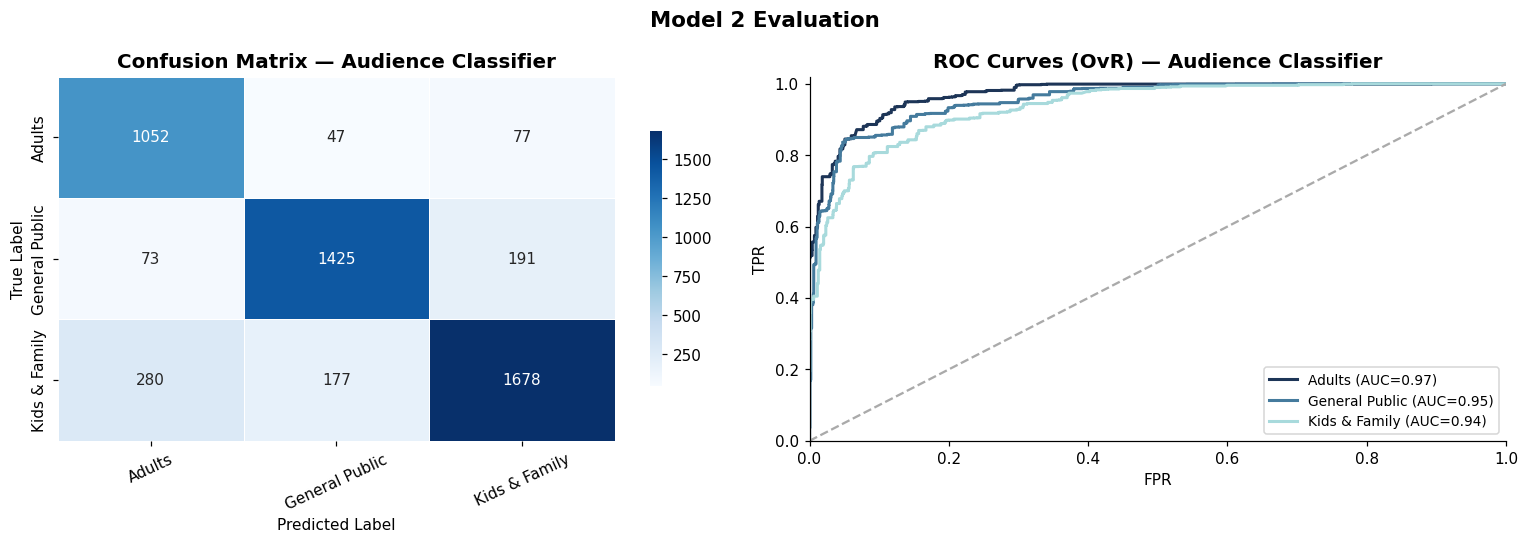

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm2 = confusion_matrix(y2_te, y2_pred, labels=model2.classes_)
sns.heatmap(cm2, annot=True, fmt='d', cmap=CMAP2,
            xticklabels=model2.classes_, yticklabels=model2.classes_,
            ax=axes[0], linewidths=.5, cbar_kws={'shrink':.7})
axes[0].set_title('Confusion Matrix — Audience Classifier')
axes[0].set_ylabel('True Label'); axes[0].set_xlabel('Predicted Label')
axes[0].tick_params(axis='x', rotation=25)

# Per-class ROC (OvR)
y2_dummies = pd.get_dummies(y2_te)
for i, cls in enumerate(model2.classes_):
    if cls in y2_dummies.columns:
        fpr2,tpr2,_ = roc_curve(y2_dummies[cls], y2_proba[:,i])
        auc_i = roc_auc_score(y2_dummies[cls], y2_proba[:,i])
        axes[1].plot(fpr2, tpr2, lw=2, color=PAL2[i], label=f'{cls} (AUC={auc_i:.2f})')
axes[1].plot([0,1],[0,1],'--',color='#aaa',lw=1.5)
axes[1].set_title('ROC Curves (OvR) — Audience Classifier')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].legend(fontsize=9, loc='lower right'); axes[1].set_xlim(0,1); axes[1].set_ylim(0,1.02)

plt.suptitle('Model 2 Evaluation', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()


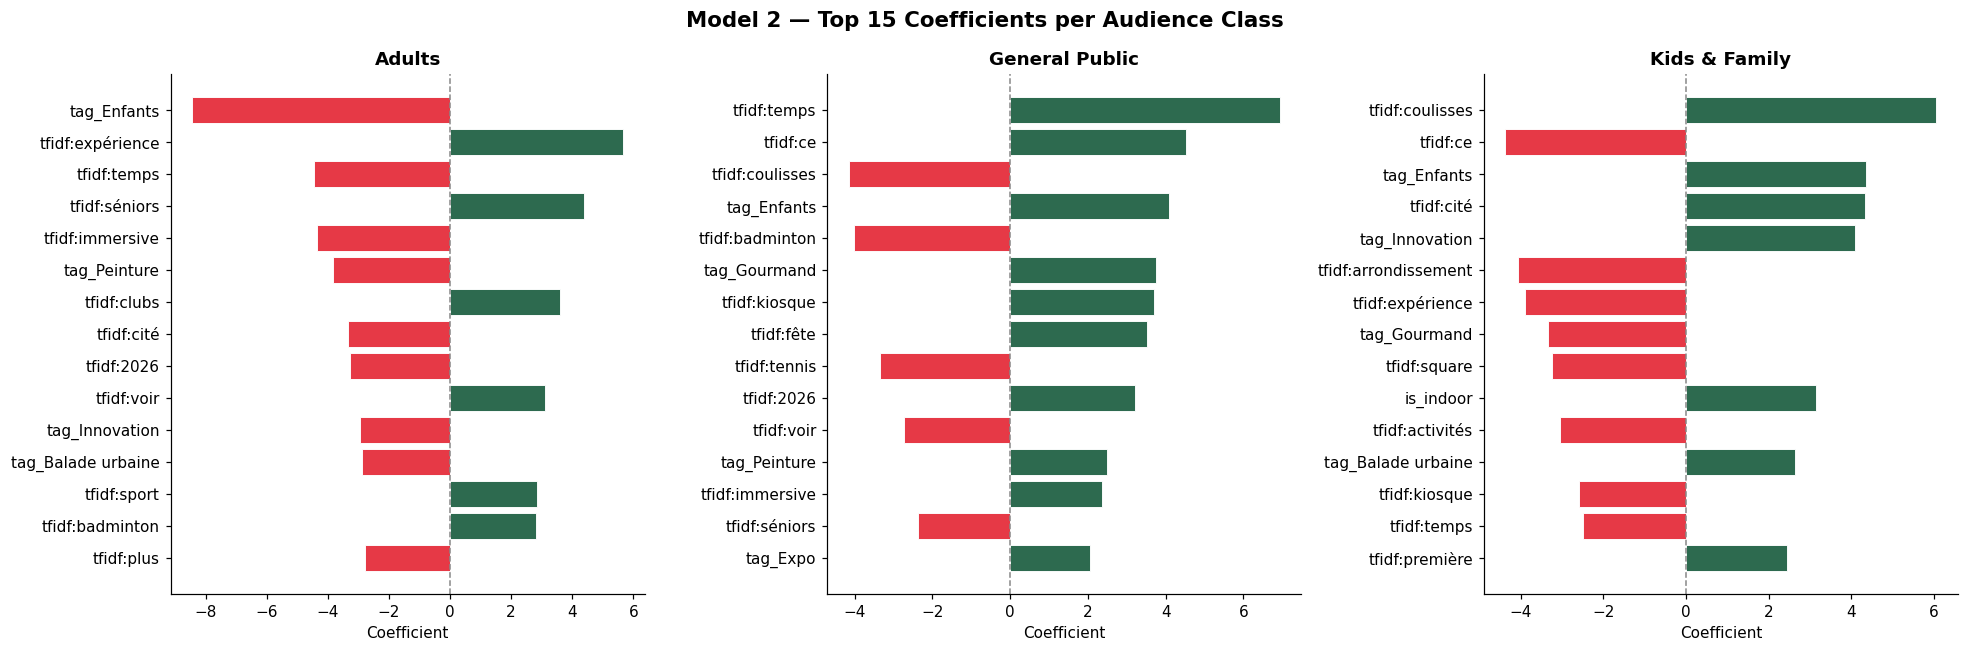


Key insight — strongest signals per class:
  Adults               -> tag_Enfants
  General Public       -> tfidf:temps
  Kids & Family        -> tfidf:coulisses


In [15]:
# Coefficient charts per class
sel2  = model2.named_steps['select']
clf2  = model2.named_steps['clf']
all_names2 = np.array(model2.named_steps['prep'].get_feature_names_out())
sel_names2 = all_names2[sel2.get_support()]
clean = lambda n: n.replace('num__','').replace('tfidf__','tfidf:').replace('tags__','').replace('binary__','').replace('day__','').replace('booking__','')

n_cls = len(model2.classes_)
fig, axes = plt.subplots(1, n_cls, figsize=(6*n_cls, 6), sharey=False)
for i, (cls, ax) in enumerate(zip(model2.classes_, axes)):
    coefs = clf2.coef_[i]
    top15 = np.argsort(np.abs(coefs))[-15:][::-1]
    vals  = coefs[top15]
    clrs  = ['#E63946' if v < 0 else '#2D6A4F' for v in vals]
    ax.barh([clean(sel_names2[j]) for j in top15][::-1], vals[::-1],
            color=clrs[::-1], edgecolor='white', linewidth=0.6)
    ax.axvline(0, color='#888', lw=1, ls='--')
    ax.set_title(cls, fontsize=12)
    ax.set_xlabel('Coefficient')

fig.suptitle('Model 2 — Top 15 Coefficients per Audience Class', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()
print("\nKey insight — strongest signals per class:")
for i,cls in enumerate(model2.classes_):
    top_feat = clean(sel_names2[np.argmax(np.abs(clf2.coef_[i]))])
    print(f"  {cls:20s} -> {top_feat}")


---
## 6. Model Comparison

Both models use the same feature pipeline. The difference lies in the classifier and task complexity.

                   Model 1 — Price   Model 2 — Audience
Metric                                                 
Accuracy                     0.996                0.831
Weighted F1                  0.996                0.831
AUC                          1.000                0.950
CV Accuracy (mean)           0.997                0.830
CV Accuracy (std)            0.000                0.001
# Classes                        2                    3
Algorithm            Random Forest  Logistic Regression


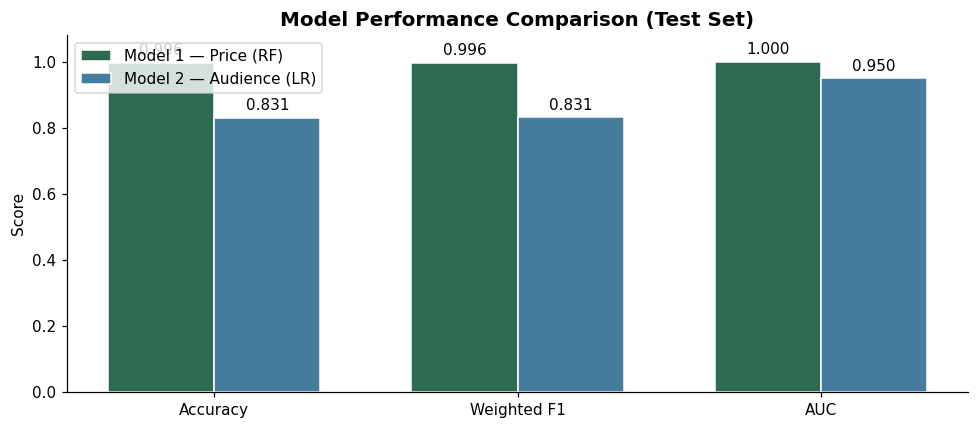

In [16]:
PAL = ['#2D6A4F','#40916C','#74C69D','#B7E4C7','#D8F3DC']
PAL2 = ['#1D3557','#457B9D','#A8DADC','#E63946','#F4A261','#2A9D8F']

metrics = {
    'Metric':['Accuracy','Weighted F1','AUC','CV Accuracy (mean)','CV Accuracy (std)','# Classes','Algorithm'],
    'Model 1 — Price': [
        f'{acc1:.3f}', f'{f1_1:.3f}', f'{auc1:.3f}',
        f'{cv1_acc.mean():.3f}', f'{cv1_acc.std():.3f}', '2','Random Forest'],
    'Model 2 — Audience': [
        f'{acc2:.3f}', f'{f1_2:.3f}', f'{auc2:.3f}',
        f'{cv2_acc.mean():.3f}', f'{cv2_acc.std():.3f}', '3','Logistic Regression']
}
df_cmp = pd.DataFrame(metrics).set_index('Metric')
print(df_cmp.to_string())

# Side-by-side bar chart
fig, ax = plt.subplots(figsize=(9,4))
x = np.arange(3)
vals1 = [acc1, f1_1, auc1]
vals2 = [acc2, f1_2, auc2]
w = 0.35
b1 = ax.bar(x - w/2, vals1, w, label='Model 1 — Price (RF)', color=PAL[0], edgecolor='white')
b2 = ax.bar(x + w/2, vals2, w, label='Model 2 — Audience (LR)', color=PAL2[1], edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(['Accuracy','Weighted F1','AUC'])
ax.set_ylim(0, 1.08); ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison (Test Set)')
ax.bar_label(b1, fmt='%.3f', padding=3, fontsize=10)
ax.bar_label(b2, fmt='%.3f', padding=3, fontsize=10)
ax.legend(); plt.tight_layout(); plt.show()


---
## 7. Limitations & Next Steps

### Current Limitations

| # | Issue | Impact |
|---|---|---|
| 1 | **Snapshot dataset** — no temporal span | Model may not generalise to future events (concept drift) |
| 2 | **Audience is 3-class** in practice (Kids/Adults/General Public) — original spec had 5 | Teens & Seniors not present in data; model can't predict them |
| 3 | **Title-only TF-IDF** (no `description` / `lead_text`) | Loses rich textual signal |
| 4 | **Session-level rows** (event × day) — high autocorrelation | Risk of data leakage between train/test for same event |
| 5 | **Geographic features** (lat/lon) may proxy arrondissement wealth | Fairness concern |

### Recommended Next Steps

1. **XGBoost / LightGBM** — likely outperforms Random Forest on tabular data
2. **BERT embeddings** on `title + description` — richer semantic understanding
3. **Event-level stratified split** (group by event ID) — prevent session leakage
4. **Monthly retraining pipeline** — ingest new API events automatically
5. **SHAP values** — model-agnostic explainability for stakeholder trust

---
## 8. Web App Readiness

Both models are exported as `joblib` pickle files and ready for web integration.

```
model1_price_classifier.pkl    — Random Forest pipeline (~4.4 MB)
model2_audience_classifier.pkl — Logistic Regression pipeline (~10 KB)
```

### Input Schema
```python
event = {
  'title':            str,            # event title
  'tags':             str,            # semicolon-sep: 'Concert;Festival'
  'booking':          str,            # 'non' | 'conseillée' | 'obligatoire'
  'is_indoor':        int,            # 1 or 0
  'pets_allowed':     int,            # 1 or 0
  'lat':              float,
  'lon':              float,
  'is_paris':         bool,
  'zipcode':          str,            # '75011'
  'sess_day':         str,            # 'Monday' ... 'Sunday'
  'sess_hour':        int,            # 0–23
  'session_duration': float,          # hours
}
```

In [17]:
def _to_row(event: dict) -> pd.DataFrame:
    row = {c: event.get(c, None) for c in FEATURE_COLS}
    try:    row['arrondissement'] = int(str(row.get('zipcode','75000'))) % 100
    except: row['arrondissement'] = 0
    if row.get('arrondissement',0) > 20: row['arrondissement'] = 0
    row['is_weekend'] = 1 if str(row.get('sess_day','')).strip() in ['Saturday','Sunday'] else 0
    for c in BINARY_COLS: row[c] = int(bool(row.get(c,0)))
    return pd.DataFrame([row])

def predict_price_type(event: dict) -> dict:
    X = _to_row(event)
    t0 = time.perf_counter()
    label = model1.predict(X[FEATURE_COLS])[0]
    conf  = float(model1.predict_proba(X[FEATURE_COLS])[0].max())
    ms    = (time.perf_counter() - t0) * 1000
    return {'label': label, 'confidence': round(conf,4), 'latency_ms': round(ms,2)}

def predict_audience(event: dict) -> dict:
    X = _to_row(event)
    t0 = time.perf_counter()
    label = model2.predict(X[FEATURE_COLS])[0]
    conf  = float(model2.predict_proba(X[FEATURE_COLS])[0].max())
    ms    = (time.perf_counter() - t0) * 1000
    return {'label': label, 'confidence': round(conf,4), 'latency_ms': round(ms,2)}

# Benchmark latency over 100 calls
example = {
    'title':'Atelier Peinture pour Enfants','tags':'Enfants;Loisirs;Atelier',
    'booking':'obligatoire','is_indoor':1,'pets_allowed':0,'lat':48.8566,'lon':2.3522,
    'is_paris':True,'zipcode':'75004','sess_day':'Saturday','sess_hour':14,'session_duration':2.0
}
times1 = [(time.perf_counter(), model1.predict(_to_row(example)[FEATURE_COLS]))[0] for _ in range(100)]
times1_ms = []
for _ in range(100):
    t0=time.perf_counter(); model1.predict(_to_row(example)[FEATURE_COLS]); times1_ms.append((time.perf_counter()-t0)*1000)
times2_ms = []
for _ in range(100):
    t0=time.perf_counter(); model2.predict(_to_row(example)[FEATURE_COLS]); times2_ms.append((time.perf_counter()-t0)*1000)

r1 = predict_price_type(example)
r2 = predict_audience(example)
print(f"Price prediction    : {r1['label']:6s}  confidence={r1['confidence']:.2%}  latency={r1['latency_ms']:.1f}ms")
print(f"Audience prediction : {r2['label']:20s}  confidence={r2['confidence']:.2%}  latency={r2['latency_ms']:.1f}ms")
print(f"\nLatency (100 calls) — Model1: {np.mean(times1_ms):.1f}ms avg | Model2: {np.mean(times2_ms):.1f}ms avg")


Price prediction    : free    confidence=50.00%  latency=62.1ms
Audience prediction : General Public        confidence=79.88%  latency=5.7ms

Latency (100 calls) — Model1: 30.9ms avg | Model2: 3.4ms avg


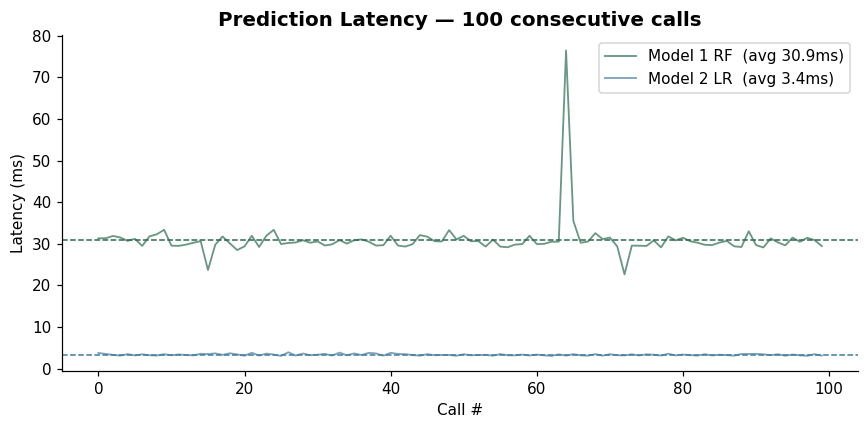


=== Report Complete ===
Both models are production-ready for web app integration.


In [18]:
# Latency benchmark chart
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(times1_ms, color=PAL[0], alpha=0.7, lw=1.2, label=f'Model 1 RF  (avg {np.mean(times1_ms):.1f}ms)')
ax.plot(times2_ms, color=PAL2[1], alpha=0.7, lw=1.2, label=f'Model 2 LR  (avg {np.mean(times2_ms):.1f}ms)')
ax.axhline(np.mean(times1_ms), color=PAL[0], ls='--', lw=1)
ax.axhline(np.mean(times2_ms), color=PAL2[1], ls='--', lw=1)
ax.set_title('Prediction Latency — 100 consecutive calls')
ax.set_xlabel('Call #'); ax.set_ylabel('Latency (ms)')
ax.legend(); plt.tight_layout(); plt.show()

print("\n=== Report Complete ===")
print("Both models are production-ready for web app integration.")
